In [1]:
import torch
import sys
sys.path.insert(0, './../')
#from utils import *

import numpy as np
import os
import time
from torch import nn
from torch import optim
from torch.autograd import grad
import time

from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
if torch.cuda.is_available():
    torch.cuda.manual_seed(88)
    torch.cuda.manual_seed_all(88)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cpu") # torch.device("cuda:0") if torch.cuda.is_available()
print('Device', device)

Device cpu


## Import reconstructed quantities of interest from 2-stream PIC simulation and visualize

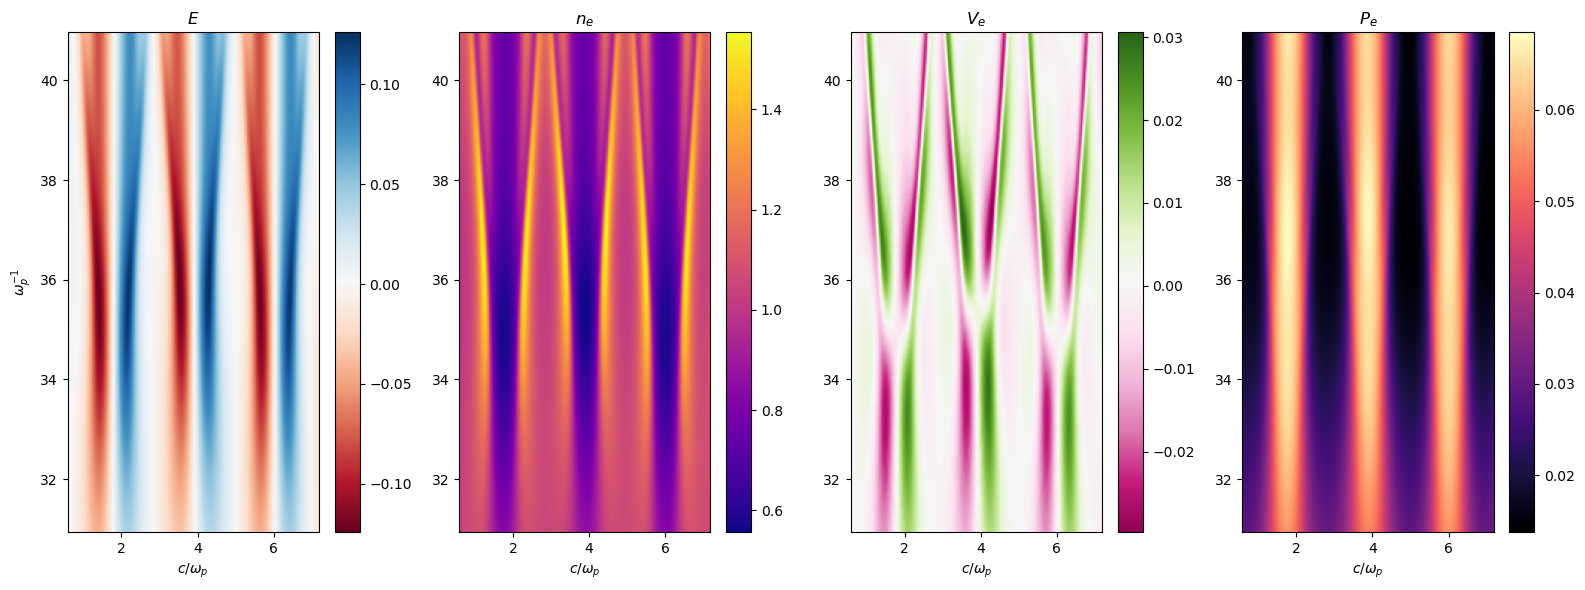

In [3]:
import pickle
def load_obj(file_path):
    with open(file_path, 'rb') as f:
        return pickle.load(f)

# Loading field data (change this path if it is in a different location)
fld_data = load_obj('/home/zbpine/mydir/Data/fld_data_c_4e5_quadratic.pkl') 
# Loading species data (change this path if it is in a different location)
spec_data = load_obj('/home/zbpine/mydir/Data/spec_data_4e5_quadratic.pkl')

#print(list(fld_data.keys()))
#print(list(spec_data.keys()))

x_cuda_tensor = torch.tensor(fld_data['x'], device=device).float()
t_cuda_tensor = torch.tensor(fld_data['t'], device=device).float()
E_cuda_tensor = torch.tensor(fld_data['E'], device=device).float()
N_cuda_tensor = torch.tensor(spec_data['N'], device=device).float()
V_cuda_tensor = torch.tensor(spec_data['<V>'], device=device).float()
P_cuda_tensor = torch.tensor(spec_data['P'], device=device).float()

# This is the window of the data that we will focus on for reconstruction

xmin = 0.6
xmax = 7.2
tmin = 31.0
tmax = 41.0

i_xmin = np.where(fld_data['x'] < xmin)[-1][-1]
i_xmax = np.where(fld_data['x'] < xmax)[-1][-1]
i_tmin = np.where(fld_data['t'] < tmin)[-1][-1]
i_tmax = np.where(fld_data['t'] < tmax)[-1][-1]

ext = [fld_data['x'][i_xmin], fld_data['x'][i_xmax], fld_data['t'][i_tmin], fld_data['t'][i_tmax]]

plt.figure(figsize=(16,6))

plt.subplot(1,4,1)
plt.imshow(fld_data['E'][i_tmin:i_tmax,i_xmin:i_xmax], origin='lower', aspect='auto', extent=ext, cmap='RdBu')
plt.colorbar()
plt.title(r'$E$')
plt.xlabel(r'$c / \omega_p$')
plt.ylabel(r'$\omega_p^{-1}$')

plt.subplot(1,4,2)
plt.imshow(spec_data['N'][i_tmin:i_tmax,i_xmin:i_xmax], origin='lower', aspect='auto', extent=ext, cmap='plasma')
plt.colorbar()
plt.title(r'$n_e$')
plt.xlabel(r'$c / \omega_p$')

plt.subplot(1,4,3)
plt.imshow(spec_data['<V>'][i_tmin:i_tmax,i_xmin:i_xmax], origin='lower', aspect='auto', extent=ext, cmap='PiYG')
plt.colorbar()
plt.title(r'$V_e$')
plt.xlabel(r'$c / \omega_p$')

plt.subplot(1,4,4)

spec_data['P'] = spec_data['N<UV>'] - spec_data['N<U>']*spec_data['<V>']
plt.imshow(spec_data['P'][i_tmin:i_tmax,i_xmin:i_xmax], origin='lower', aspect='auto', extent=ext, cmap='magma')
plt.colorbar()
plt.title(r'$P_e$')
plt.xlabel(r'$c / \omega_p$')

plt.tight_layout()
plt.show()

### Explicitly compute the residuals on the data, and visualize them

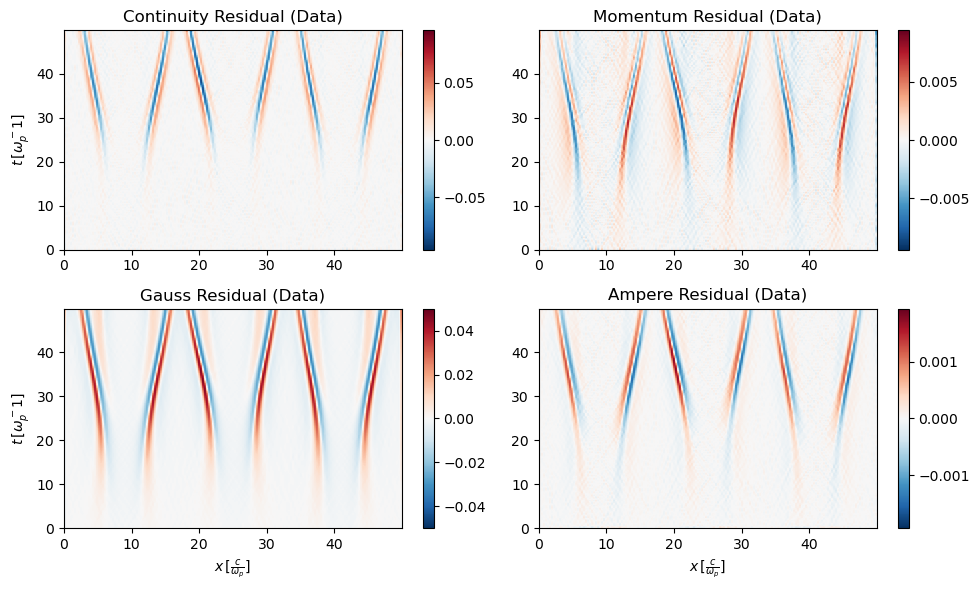

In [4]:
def derivative_x(quantity, dx):
    
    quantity_x = np.zeros_like(quantity)
    
    for j in range(1,quantity_x.shape[1]-1):
        quantity_x[:, j] = (quantity[:, j+1] - quantity[:, j-1]) / (2.0*dx)
        
    quantity_x[:,0] = (quantity[:,1] - quantity[:,0]) / dx
    quantity_x[:,-1] = (quantity[:,-1] - quantity[:,-2]) / dx
    
    return quantity_x

def derivative_x_forward(quantity, dx):
    
    quantity_x = np.zeros_like(quantity)
    
    for j in range(quantity_x.shape[1]-1):
        quantity_x[:, j] = (quantity[:, j+1] - quantity[:, j]) / dx
    
    quantity_x[:,-1] = (quantity[:,0] - quantity[:,-1]) / dx
    
    return quantity_x

def derivative_t(quantity, dt):
    
    quantity_t = np.zeros_like(quantity)
    
    for i in range(1,quantity_t.shape[0]-1):
        quantity_t[i,:] = (quantity[i+1,:] - quantity[i-1,:]) / (2.0*dt)
    
    quantity_t[0,:] = (quantity[1,:] - quantity[0,:]) / dt
    quantity_t[-1,:] = (quantity[-1,:] - quantity[-2,:]) / dt
    
    return quantity_t

E = fld_data['E'][i_tmin:i_tmax,i_xmin:i_xmax]
N = spec_data['N'][i_tmin:i_tmax,i_xmin:i_xmax]
V = spec_data['<V>'][i_tmin:i_tmax,i_xmin:i_xmax]
P = spec_data['P'][i_tmin:i_tmax,i_xmin:i_xmax]

E_x = derivative_x(E, fld_data['dx'])
E_t = derivative_t(E, fld_data['dt'])
N_x = derivative_x(N, fld_data['dx'])
N_t = derivative_t(N, fld_data['dt'])
V_x = derivative_x(V, fld_data['dx'])
V_t = derivative_t(V, fld_data['dt'])
P_x = derivative_x(P, fld_data['dx'])

continuity = N_t + V*N_x + N*V_x
momentum = N*(V_t + V*V_x) + N*E + P_x
gauss = E_x - (1. - N)
ampere = E_t - N*V

continuity_max = np.max(np.abs(continuity))
momentum_max = np.max(np.abs(momentum))
gauss_max = np.max(np.abs(gauss))
ampere_max = np.max(np.abs(ampere))

nrows, ncols = (2,2)
    
plt.figure(figsize=(10,6))

data = [continuity, momentum, gauss, ampere]
titles = ['Continuity Residual (Data)', 'Momentum Residual (Data)', 'Gauss Residual (Data)', 'Ampere Residual (Data)']
origin = 'lower'
aspect = 'auto'
cmaps = ['RdBu_r', 'RdBu_r', 'RdBu_r', 'RdBu_r']
xlabel = r'$x \, [\frac{c}{\omega_p}]$'
ylabel = r'$t \, [\omega_p^-1]$'
vmins = [-1.0*continuity_max, -1.0*momentum_max, -1.0*gauss_max, -1.0*ampere_max]
vmaxs = [continuity_max, momentum_max, gauss_max, ampere_max]
ext = [fld_data['x'][0], fld_data['x'][-1], fld_data['t'][0], fld_data['t'][-1]]

for i in range(nrows):
        
    for j in range(ncols):
            
        num = j + i*ncols
            
        plt.subplot(nrows, ncols, num+1)
        plt.title(titles[num])
        plt.imshow(data[num], origin=origin, extent=ext, aspect=aspect, cmap=cmaps[num], vmin=vmins[num], vmax=vmaxs[num])
            
        if i == nrows - 1:
            plt.xlabel(xlabel)
        if j == 0:
            plt.ylabel(ylabel)
                
        plt.colorbar()

plt.tight_layout()
plt.show()

## Activation function classes

In [5]:
### Here we define a few choices of activation functions / nonlinearities that are commonly used in the PINN literature

def init_param(w0, device):
    
    return nn.Parameter(torch.tensor(w0, dtype=torch.float32, device=device))

class Sin(nn.Module):

    def __init__(self, device, w0=1.):
        
        super(Sin, self).__init__()
        self.w0 = init_param(w0, device)

    def forward(self, x):
        return torch.sin(self.w0 * x)

class Tanh(nn.Module):

    def __init__(self, device, w0=1.):
        
        super(Tanh, self).__init__()
        self.w0 = init_param(w0, device)

    def forward(self, x):
        return torch.tanh(self.w0 * x)

class Swish(nn.Module):

    def __init__(self, device, w0=1.):
        
        super(Swish, self).__init__()
        self.w0 = init_param(w0, device)

    def forward(self, x):
        return x * torch.sigmoid(self.w0 * x)

### Network classes

In [6]:
class MLP(nn.Module):

    #### Initialize the MLP class. This is the neural network (NN) architecture that constitutes the PINN

    def __init__(self, extent, device, num_hidden_layers=4, hidden_size=50, activation='sin'):

        super(MLP, self).__init__()

        # These are used for normalizing the input to be in the range [-1, 1]. This speeds up convergence. 
        self.xmin = torch.tensor(extent[0], dtype=torch.float32, requires_grad=False, device=device)
        self.xmax = torch.tensor(extent[1], dtype=torch.float32, requires_grad=False, device=device)
        self.tmin = torch.tensor(extent[2], dtype=torch.float32, requires_grad=False, device=device)
        self.tmax = torch.tensor(extent[3], dtype=torch.float32, requires_grad=False, device=device)

        self.num_hidden_layers = num_hidden_layers # number of hidden layers, i.e. the depth of the neural network
        self.hidden_size = hidden_size             # number of 'nodes', i.e. the width of the neural network
        self.input_size = 2                        # 2 input dimensions - x and t
        self.output_size = 4                       # 4 output quantities - E, n_e, V_e, P_e

        if activation == 'tanh' or activation == 'Tanh':
            self.activation_fn = Tanh(device)
            
        elif activation == 'sin' or activation == 'Sin':
            self.activation_fn = Sin(device)
            
        elif activation == 'swish' or activation == 'Swish':
            self.activation_fn = Swish(device)

        ### This is where the actual architecture is built. It is a series of linear transformations --> activation functions / nonlinearities.
        self.network = nn.Sequential()

        self.network.add_module('input_linear', nn.Linear(self.input_size, self.hidden_size))
        self.network.add_module('input_activation', self.activation_fn)

        for i in range(self.num_hidden_layers):
            self.network.add_module(f'hidden_layer_{i+1}', nn.Linear(self.hidden_size, self.hidden_size))
            self.network.add_module(f'hidden_activation_{i+1}', self.activation_fn)

        self.network.add_module('output_linear', nn.Linear(self.hidden_size, self.output_size))

    ### All MLP's must implement a 'forward pass'. This is how the network predicts the solution based on the input.
    ### The input vectors are concatenated into an (N, 2) matrix ---> N = number of points to predict, 2 = number of input dims (x and t).
    ### Then the series of linear transformations ---> activation functions / nonlinearities are performed until we get to the output layer,
    ### from which the predicted values are received.

    ### So the dimensionality of the matrix ops. are as follows:

    # input layer: (N_points, 2) x (2, num_nodes) = (N_points, num_nodes). Then we apply an element-wise activation function.
    # first hidden layer: (N_points, num_nodes) x (num_nodes, num_nodes) = (N_points, num_nodes). Apply an element-wise activation function.
    # second hidden layer: (N_points, num_nodes) x (num_nodes, num_nodes) = (N_points, num_nodes). Apply an element-wise activation function.
    # etc. etc. until the output layer
    # output layer: (N_points, num_nodes) x (num_nodes, output_size) = (N_points, output_size). No activation function is applied here.

    ### So the final output shape will be (N_points, 4) in our case, with output_size = 4.
    
    def forward(self, x, t):

        # This operation normalizes the input coordinates to be contained within the range [-1, 1].
        x = 2.0*((x - self.xmin) / (self.xmax - self.xmin)) - 1
        t = 2.0*((t - self.tmin) / (self.tmax - self.tmin)) - 1

        inp = torch.cat((x, t), dim=1)
        u = self.network(inp)

        return u

## Full state reconstruction from sparse measurements using fluid equations

In [7]:
def fluid_eqs(PINN, x, t):
    
    residuals = torch.zeros(x.size(dim=0), 4).to(device)

    # Forward pass to get predictions on collocation points, which is used to get derivatives d/dx and d/dt
    E, N, V, P = (PINN(x,t)*PINN.norm + PINN.mean).T

    E = E.reshape(-1,1)
    N = N.reshape(-1,1)
    V = V.reshape(-1,1)
    P = P.reshape(-1,1)

    E_t = torch.autograd.grad(E, t, grad_outputs=torch.ones_like(E), retain_graph=True, create_graph=True)[0]
    E_x = torch.autograd.grad(E, x, grad_outputs=torch.ones_like(E), retain_graph=True, create_graph=True)[0]
    N_t = torch.autograd.grad(N, t, grad_outputs=torch.ones_like(N), retain_graph=True, create_graph=True)[0]
    N_x = torch.autograd.grad(N, x, grad_outputs=torch.ones_like(N), retain_graph=True, create_graph=True)[0]
    V_t = torch.autograd.grad(V, t, grad_outputs=torch.ones_like(V), retain_graph=True, create_graph=True)[0]
    V_x = torch.autograd.grad(V, x, grad_outputs=torch.ones_like(V), retain_graph=True, create_graph=True)[0]
    P_x = torch.autograd.grad(P, x, grad_outputs=torch.ones_like(P), retain_graph=True, create_graph=True)[0]

    residuals[:,0:1] = N_t + V*N_x + N*V_x             # mass continuity of electrons
    residuals[:,1:2] = N*(V_t + V*V_x) + P_x + N*E     # electron momentum equation (x-component only)
    residuals[:,2:3] = E_x - (torch.ones_like(N) - N)  # gauss' law
    residuals[:,3:4] = E_t - N*V                       # ampere's law

def fluid_eqs_discrete(PINN, x, t, dx, dt):

    residuals = torch.zeros(x.size(dim=0), 4).to(device)
    
    x_phdx = x + 0.5*dx*torch.ones(x.size(), device=device)
    x_mhdx = x - 0.5*dx*torch.ones(x.size(), device=device)
    t_phdt = t + 0.5*dt*torch.ones(t.size(), device=device)
    t_mhdt = t - 0.5*dt*torch.ones(t.size(), device=device)

    # We forward pass several times to compute derivatives using finite differences
    E, N, V, P                     = (PINN(x,t) * PINN.norm + PINN.mean).T
    E_phdx, N_phdx, V_phdx, P_phdx = (PINN(x_phdx,t) * PINN.norm + PINN.mean).T
    E_mhdx, N_mhdx, V_mhdx, P_mhdx = (PINN(x_mhdx,t) * PINN.norm + PINN.mean).T
    E_phdt, N_phdt, V_phdt, P_phdt = (PINN(x,t_phdt) * PINN.norm + PINN.mean).T
    E_mhdt, N_mhdt, V_mhdt, P_mhdt = (PINN(x,t_mhdt) * PINN.norm + PINN.mean).T

    E_x = (E_phdx - E_mhdx) / dx
    E_t = (E_phdt - E_mhdt) / dt
    N_t = (N_phdt - N_mhdt) / dt
    N_x = (N_phdx - N_mhdx) / dx
    V_x = (V_phdx - V_mhdx) / dx
    V_t = (V_phdt - V_mhdt) / dt
    P_x = (P_phdx - P_mhdx) / dx
    
    residuals[:,0] = N_t + V*N_x + N*V_x          # mass continuity of electrongs
    residuals[:,1] = N*(V_t + V*V_x) + P_x + N*E    # electron momentum equation
    residuals[:,2] = E_x - (torch.ones_like(N) - N) # gauss' law
    residuals[:,3] = E_t - N*V                      # ampere's law
    
    return residuals

In [8]:
############# Random interior measurements points ########

def sample_sparse_measurements(n_sparse_measurements, i_xmin, i_xmax, i_tmin, i_tmax):

    n_train = int(0.8*n_sparse_measurements)
    
    n_x = i_xmax - i_xmin
    n_t = i_tmax - i_tmin
    
    x_idx = []
    t_idx = []
    x_val = []
    t_val = []
    E_val = []
    N_val = []
    V_val = []
    P_val = []

    i_x_sm = np.random.randint(i_xmin,i_xmax+1, n_sparse_measurements)
    i_t_sm = np.random.randint(i_tmin,i_tmax+1, n_sparse_measurements)

    for i_x, i_t in zip(i_x_sm,i_t_sm):
        x_val.append(fld_data['x'][i_x])
        t_val.append(fld_data['t'][i_t] - fld_data['t'][i_tmin])

        E_val.append(fld_data['E'][i_t, i_x])
        N_val.append(spec_data['N'][i_t, i_x])
        V_val.append(spec_data['<V>'][i_t, i_x])
        P_val.append(spec_data['P'][i_t, i_x])

    x_sm = torch.from_numpy(np.array(x_val[:n_train])).float().reshape(-1,1).to(device)
    t_sm = torch.from_numpy(np.array(t_val[:n_train])).float().reshape(-1,1).to(device)
    E_sm = torch.from_numpy(np.array(E_val[:n_train])).float().reshape(-1,1).to(device)
    N_sm = torch.from_numpy(np.array(N_val[:n_train])).float().reshape(-1,1).to(device)
    V_sm = torch.from_numpy(np.array(V_val[:n_train])).float().reshape(-1,1).to(device)
    P_sm = torch.from_numpy(np.array(P_val[:n_train])).float().reshape(-1,1).to(device)

    x_test = torch.from_numpy(np.array(x_val[n_train:])).float().reshape(-1,1).to(device)
    t_test = torch.from_numpy(np.array(t_val[n_train:])).float().reshape(-1,1).to(device)
    E_test = torch.from_numpy(np.array(E_val[n_train:])).float().reshape(-1,1).to(device)
    N_test = torch.from_numpy(np.array(N_val[n_train:])).float().reshape(-1,1).to(device)
    V_test = torch.from_numpy(np.array(V_val[n_train:])).float().reshape(-1,1).to(device)
    P_test = torch.from_numpy(np.array(P_val[n_train:])).float().reshape(-1,1).to(device)
    
    return x_sm, t_sm, torch.cat((E_sm, N_sm, V_sm, P_sm), 1), x_test, t_test, torch.cat((E_test, N_test, V_test, P_test), 1)

def get_collocation_pts(i_xmin, i_xmax, i_tmin, i_tmax):
    
    # collocation points for calculating the residuals, 
    # sampled on the full grid within the domain of interest
    
    x_val = []
    t_val = []
    E_val = []
    N_val = []
    V_val = []
    P_val = []
    
    for xs in range(i_xmin, i_xmax, 1):
        for ts in np.arange(i_tmin, i_tmax, 1):
            x_val.append(fld_data['x'][xs])
            t_val.append(fld_data['t'][ts] - fld_data['t'][i_tmin]) # here we reshift time to start at t_idx = 220

    x_i     = torch.from_numpy(np.array(x_val)).float().reshape(-1,1).to(device)
    t_i     = torch.from_numpy(np.array(t_val)).float().reshape(-1,1).to(device)
    
    return x_i, t_i

In [9]:
def optimize_PINN(PINN, num_epochs, optimizer, hist, x_sm, t_sm, ENVP_sm, x_i, t_i):
    
    sampling_time = 0.0
    sm_time = 0.0
    physics_time = 0.0
    optimization_time = 0.0
    write_time = 0.0
    scheduling_time = 0.0
    
    for epoch in range(1, num_epochs+1):
        
        start_time = time.time()
        n_i = x_i.shape[0]
        i_idxs = np.random.choice(n_i, size = n_i, replace = False)
        end_time = time.time()
        sampling_time += end_time - start_time

        n_batches = 50
        
        for i in range(n_batches):

            ## Compute sparse measurement loss (quantitative measure of how well the prediction fits to the data)
            
            start_time = time.time()
            pinn_sm_pts = PINN(x_sm, t_sm) # Forward pass to get predictions for sparse measurements points
                
            loss_bc = torch.mean(torch.square(pinn_sm_pts - ((ENVP_sm - PINN.mean) / PINN.norm))) # Note we normalize to the std of the data. This accelerates convergence
            end_time = time.time()
            sm_time += end_time - start_time
            
            start_time = time.time()
            hist['sm_loss'].append(loss_bc.item())
            end_time = time.time()
            write_time += end_time - start_time

            ## Compute physics loss (quantitative measure of how well the prediction obeys the governing equations)
            
            start_time = time.time()
            x_i_batch     = x_i[i_idxs[i::n_batches],:]
            t_i_batch     = t_i[i_idxs[i::n_batches],:]
            
            residuals = fluid_eqs_discrete(PINN, x_i_batch, t_i_batch, \
                                           dx=fld_data['dx'], \
                                           dt=fld_data['dt'] / 2)

            loss_continuity = torch.mean(torch.square(residuals[:,0]))
            loss_momentum   = torch.mean(torch.square(residuals[:,1]))
            loss_gauss      = torch.mean(torch.square(residuals[:,2]))
            loss_ampere     = torch.mean(torch.square(residuals[:,3]))
            
            loss_physics    = loss_continuity + loss_momentum + loss_gauss + loss_ampere
            end_time = time.time()
            physics_time += end_time - start_time

            start_time = time.time()
            hist['phys_loss'].append(loss_physics.item())
            end_time = time.time()
            write_time += end_time - start_time

            ## Compute total loss (aggregate sparse measurement + physics loss)
            start_time  = time.time()
            loss = loss_bc + 10.0*loss_physics # This weight can be modified to an arbitrary value; this was observed to give good results
            end_time = time.time()
            optimization_time += end_time - start_time

            start_time = time.time()
            hist['total_loss'].append(loss.item())
            end_time = time.time()
            write_time += end_time - start_time

            ## This is where the heavy lifting happens. First we clear out previous gradients of the loss.
            ## Then we perform a backward pass, which yields d(Total loss) / d(parameter_i) for ALL parameters i.
            ## Then we use these gradients to step the network's parameters in the direction of the negative gradient using the Adam optimizer.
            ## See https://builtin.com/machine-learning/adam-optimization
            
            start_time = time.time()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            end_time = time.time()
            optimization_time += end_time - start_time
            
            start_time = time.time()
            lr = get_lr(optimizer)
            end_time = time.time()
            scheduling_time += end_time - start_time
            
            start_time = time.time()
            hist['lr'].append(lr)
            end_time = time.time()
            write_time += end_time - start_time
            
        # Here we improve our model's accuracy by making the learning rate smaller when the loss progress stalls.
        # This is called learning rate scheduling. Essentially it means that we take smaller parameter steps when we approach
        # a minimum in the loss.
        # See here for more info: https://towardsdatascience.com/learning-rate-schedules-and-adaptive-learning-rate-methods-for-deep-learning-2c8f433990d1
        if epoch % 100 == 0:
            print('epoc = ', epoch)
            print('loss = ', float(loss))
            start_time = time.time()
            lr_new = lr_scheduler(hist['total_loss'], patience = 100*n_batches, lr = lr)
            if lr_new < lr:
                lr = lr_new
                optimizer.param_groups[0]['lr'] = lr_new
                print('lr = ', float(lr))
            end_time = time.time()
            scheduling_time += end_time - start_time
            
    total_time = sampling_time + sm_time + physics_time + optimization_time + write_time + scheduling_time
    print('\n')
    print('Training run complete. Individual times:')
    print("Sampling time: --- %s mins ---" % str(round((sampling_time)/60,2)))
    print("SM loss time: --- %s mins ---" % str(round((sm_time)/60,2)))
    print("Physics loss time: --- %s mins ---" % str(round((physics_time)/60,2)))
    print("Optimization time: --- %s mins ---" % str(round((optimization_time)/60,2)))
    print("Write time: --- %s mins ---" % str(round((write_time)/60,2)))
    print("Scheduling time: --- %s mins ---" % str(round((scheduling_time)/60,2)))
    print('\n')
    print("Total time: --- %s mins ---" % str(round((total_time)/60,2)))
                
def optimize_INN(INN, num_epochs, optimizer, hist, x_sm, t_sm, ENVP_sm):
    
    for epoch in range(1, num_epochs+1):

        n_batches = 50
        for i in range(n_batches):
            inn_sm_pts = INN(x_sm, t_sm)
            loss = torch.mean(torch.square(inn_sm_pts - ((ENVP_sm - INN.mean)/INN.norm)))
            hist['sm_loss'].append(loss.item())
            hist['total_loss'].append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            lr = get_lr(optimizer)
            hist['lr'].append(lr)

        if epoch % 100 == 0:
            print('epoc = ', epoch)
            print('loss = ', float(loss))
            lr_new = lr_scheduler(hist['total_loss'], patience = 100*n_batches, lr = lr)
            if lr_new < lr:
                lr = lr_new
                optimizer.param_groups[0]['lr'] = lr_new
                print('lr = ', float(lr))

In [10]:
def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']
    
def lr_scheduler(loss_hist, lr, patience, factor=0.5):

    smooth_loss_hist = uniform_filter1d(loss_hist, int(len(loss_hist)/10)+1)
    loss_decrease_over_patience_period = smooth_loss_hist[-1] - smooth_loss_hist[-patience]
    loss_fluctuations = loss_hist[-patience:] - smooth_loss_hist[-patience:]
    std_loss_fluctuations = np.std(loss_fluctuations[-patience:])

    if -loss_decrease_over_patience_period < std_loss_fluctuations:
        lr *= factor
    else:
        lr = lr

    return lr

In [11]:
def pinn_reconstruct(PINN, n_sparse_measurements, i_xmin, i_xmax, i_tmin, i_tmax, hist, num_epochs):
    
    # sample sparse measurements
    x_sm, t_sm, ENVP_sm, x_test, t_test, ENVP_test = sample_sparse_measurements(n_sparse_measurements = n_sparse_measurements, 
                                                     i_xmin = i_xmin, i_xmax = i_xmax, 
                                                     i_tmin = i_tmin, i_tmax = i_tmax)

    # tensor of standard deviations. We will use these to normalize our input/output. This accelerates convergence.
    norm = torch.std(ENVP_sm,0).detach()
    mean = torch.mean(ENVP_sm,0).detach()
#    norm[3] = 1.
    PINN.norm = norm
    PINN.mean = mean
    
    # get collocation points. These are used to compute residuals
    x_i, t_i = get_collocation_pts(i_xmin = i_xmin, i_xmax = i_xmax,
                               i_tmin = i_tmin, i_tmax = i_tmax)

    # main PINN optimization loop
    optimize_PINN(PINN, num_epochs, optimizer, hist,
                  x_sm, t_sm, ENVP_sm, 
                  x_i, t_i)

    compute_errors(PINN, i_xmin, i_xmax, i_tmin, i_tmax, x_sm, t_sm, x_test, t_test, ENVP_sm, ENVP_test)
    
    return PINN, hist, [x_sm, t_sm], [x_test, t_test]

def inn_reconstruct(INN, n_sparse_measurements, i_xmin, i_xmax, i_tmin, i_tmax, hist, num_epochs):
    
    # sample sparse measurements
    x_sm, t_sm, ENVP_sm, x_test, t_test, ENVP_test = sample_sparse_measurements(n_sparse_measurements = n_sparse_measurements, 
                                                     i_xmin = i_xmin, i_xmax = i_xmax, 
                                                     i_tmin = i_tmin, i_tmax = i_tmax)

    norm = torch.std(ENVP_sm,0).detach()
    mean = torch.mean(ENVP_sm,0).detach()
    INN.norm = norm
    INN.mean = mean
    

    # optimize INN
    optimize_INN(INN, num_epochs, optimizer, hist,
                  x_sm, t_sm, ENVP_sm)

    compute_errors(INN, i_xmin, i_xmax, i_tmin, i_tmax, x_sm, t_sm, x_test, t_test, ENVP_sm, ENVP_test)
    
    return INN, hist, [x_sm, t_sm], [x_test, t_test]

In [21]:
def plot_NN_reconstruction(NN, i_xmin, i_xmax, i_tmin, i_tmax, x_sm, t_sm):
    
    nx = len(fld_data['x'][i_xmin:i_xmax])
    nt = len(fld_data['t'][i_tmin:i_tmax])
    X, T = np.meshgrid(fld_data['x'][i_xmin:i_xmax],fld_data['t'][i_tmin:i_tmax]-fld_data['t'][i_tmin])
    X = torch.FloatTensor(X.flatten()).reshape(-1,1).to(device)
    T = torch.FloatTensor(T.flatten()).reshape(-1,1).to(device)

    Enn, Nnn, Vnn, Pnn = (NN(X, T) * NN.norm + NN.mean).T

    x_min, x_max = fld_data['x'][i_xmin], fld_data['x'][i_xmax]
    t_min, t_max = 0, fld_data['t'][i_tmax] - fld_data['t'][i_tmin]
    
    vmin_E = -np.max(np.abs(fld_data['E'][i_tmin:i_tmax,i_xmin:i_xmax]))
    vmax_E = np.max(np.abs(fld_data['E'][i_tmin:i_tmax,i_xmin:i_xmax]))
    vmin_N = np.min(spec_data['N'][i_tmin:i_tmax,i_xmin:i_xmax])
    vmax_N = np.max(spec_data['N'][i_tmin:i_tmax,i_xmin:i_xmax])
    vmin_V = -np.max(np.abs(spec_data['<V>'][i_tmin:i_tmax,i_xmin:i_xmax]))
    vmax_V = np.max(np.abs(spec_data['<V>'][i_tmin:i_tmax,i_xmin:i_xmax]))
    vmin_P = np.min(spec_data['P'][i_tmin:i_tmax,i_xmin:i_xmax])
    vmax_P = np.max(spec_data['P'][i_tmin:i_tmax,i_xmin:i_xmax])

    plt.figure(figsize=(10,6))
    plt.subplot(2,4,1)
    plt.title(r'$E$')
    plt.imshow(fld_data['E'][i_tmin:i_tmax,i_xmin:i_xmax], origin='lower', extent=[x_min, x_max, t_min, t_max], 
               aspect='auto', cmap = 'RdBu')
    plt.colorbar()
    plt.scatter(x_sm.detach().cpu().numpy(), t_sm.detach().cpu().numpy(), s = 1, c = 'k')

    plt.subplot(2,4,2)
    plt.title(r'$n_e$')
    plt.imshow(spec_data['N'][i_tmin:i_tmax,i_xmin:i_xmax], origin='lower', extent=[x_min, x_max, t_min, t_max], 
               aspect='auto', cmap = 'plasma')
    plt.colorbar()
    plt.scatter(x_sm.detach().cpu().numpy(), t_sm.detach().cpu().numpy(), s = 1, c = 'k')

    plt.subplot(2,4,3)
    plt.title(r'$V_e$')
    plt.imshow(spec_data['<V>'][i_tmin:i_tmax,i_xmin:i_xmax], origin='lower', extent=[x_min, x_max, t_min, t_max], 
               aspect='auto', cmap = 'PiYG')
    plt.colorbar()
    plt.scatter(x_sm.detach().cpu().numpy(), t_sm.detach().cpu().numpy(), s = 1, c = 'k')

    plt.subplot(2,4,4)
    plt.title(r'$P_e$')
    plt.imshow(spec_data['P'][i_tmin:i_tmax,i_xmin:i_xmax], origin='lower', extent=[x_min, x_max, t_min, t_max], 
               aspect='auto', cmap = 'magma')
    plt.colorbar()
    plt.scatter(x_sm.detach().cpu().numpy(), t_sm.detach().cpu().numpy(), s = 1, c = 'k')

    plt.subplot(2,4,5)
    plt.title(r'Reconstructed $E$')
    plt.imshow(Enn.reshape(nt,nx).detach().cpu().numpy(), origin='lower', extent=[x_min, x_max, t_min, t_max], 
               aspect='auto', vmin=vmin_E, vmax=vmax_E, cmap = 'RdBu')
    plt.colorbar()

    plt.subplot(2,4,6)
    plt.title(r'Reconstructed $n_e$')
    plt.imshow(Nnn.reshape(nt,nx).detach().cpu().numpy(), origin='lower', extent=[x_min, x_max, t_min, t_max], 
               aspect='auto', vmin=vmin_N, vmax=vmax_N, cmap='plasma')
    plt.colorbar()

    plt.subplot(2,4,7)
    plt.title(r'Reconstructed $V_e$')
    plt.imshow(Vnn.reshape(nt,nx).detach().cpu().numpy(), origin='lower', extent=[x_min, x_max, t_min, t_max], 
               aspect='auto', vmin=vmin_V, vmax=vmax_V, cmap='PiYG')
    plt.colorbar()

    plt.subplot(2,4,8)
    plt.title(r'Reconstructed $P_e$')
    plt.imshow(Pnn.reshape(nt,nx).detach().cpu().numpy(), origin='lower', extent=[x_min, x_max, t_min, t_max], 
               aspect='auto', cmap = 'magma') #, vmin=vmin_P, vmax=vmax_P, )
    plt.colorbar()

    plt.tight_layout()
    plt.show()
    
def plot_phys_error_distribution(NN, i_xmin, i_xmax, i_tmin, i_tmax, x_sm, t_sm):
    
    nx = len(fld_data['x'][i_xmin:i_xmax])
    nt = len(fld_data['t'][i_tmin:i_tmax])
    X, T = np.meshgrid(fld_data['x'][i_xmin:i_xmax],fld_data['t'][i_tmin:i_tmax]-fld_data['t'][i_tmin])
    X = torch.FloatTensor(X.flatten()).reshape(-1,1).to(device)
    T = torch.FloatTensor(T.flatten()).reshape(-1,1).to(device)
    
    x_min, x_max = fld_data['x'][i_xmin], fld_data['x'][i_xmax]
    t_min, t_max = 0, fld_data['t'][i_tmax] - fld_data['t'][i_tmin]
    
    residuals = fluid_eqs_discrete(NN, X, T, dx = fld_data['dx'], dt = fld_data['dt']/2)
    
    continuity_err_discr = residuals[:,0].reshape(nt,nx).detach().cpu().numpy()
    momentum_err_discr   = residuals[:,1].reshape(nt,nx).detach().cpu().numpy()
    gauss_err_discr      = residuals[:,2].reshape(nt,nx).detach().cpu().numpy()
    ampere_err_discr     = residuals[:,3].reshape(nt,nx).detach().cpu().numpy()
    
    plt.figure(figsize=(16,9))

    plt.subplot(2,2,1)
    plt.imshow(continuity_err_discr, origin='lower', aspect='auto', 
               cmap = 'RdBu', extent=[x_min, x_max, t_min, t_max], 
               vmin = -np.abs(continuity_err_discr).max(),
               vmax = np.abs(continuity_err_discr).max())
    plt.title('Continuity residuals')
    plt.colorbar()
    plt.scatter(x_sm.detach().cpu().numpy(), t_sm.detach().cpu().numpy(), s = 1, c = 'k')
    
    plt.subplot(2,2,2)
    plt.imshow(momentum_err_discr, origin='lower', aspect='auto', 
               cmap = 'RdBu', extent=[x_min, x_max, t_min, t_max], 
               vmin = -np.abs(momentum_err_discr).max(),
               vmax = np.abs(momentum_err_discr).max())
    plt.title('Momentum residuals')
    plt.colorbar()
    plt.scatter(x_sm.detach().cpu().numpy(), t_sm.detach().cpu().numpy(), s = 1, c = 'k')

    plt.subplot(2,2,3)
    plt.imshow(gauss_err_discr, origin='lower', aspect='auto', 
               cmap = 'RdBu', extent=[x_min, x_max, t_min, t_max], 
               vmin = -np.abs(gauss_err_discr).max(),
               vmax = np.abs(gauss_err_discr).max())
    plt.title('Gauss residuals')
    plt.colorbar()
    plt.scatter(x_sm.detach().cpu().numpy(), t_sm.detach().cpu().numpy(), s = 1, c = 'k')

    plt.subplot(2,2,4)
    plt.imshow(ampere_err_discr, origin='lower', aspect='auto', 
               cmap = 'RdBu', extent=[x_min, x_max, t_min, t_max], 
               vmin = -np.abs(ampere_err_discr).max(),
               vmax = np.abs(ampere_err_discr).max())
    plt.title('Ampere residuals')
    plt.colorbar()
    plt.scatter(x_sm.detach().cpu().numpy(), t_sm.detach().cpu().numpy(), s = 1, c = 'k')

    plt.tight_layout()
    plt.show()

In [13]:
def compute_errors(NN, i_xmin, i_xmax, i_tmin, i_tmax, x_sm, t_sm, x_test, t_test, \
                  ENVP_sm, ENVP_test):

    nx = len(fld_data['x'][i_xmin:i_xmax])
    nt = len(fld_data['t'][i_tmin:i_tmax])
    X, T = np.meshgrid(fld_data['x'][i_xmin:i_xmax],fld_data['t'][i_tmin:i_tmax]-fld_data['t'][i_tmin])
    X = torch.FloatTensor(X.flatten()).reshape(-1,1).to(device)
    T = torch.FloatTensor(T.flatten()).reshape(-1,1).to(device)

    with torch.no_grad():
        Enn_sm, Nnn_sm, Vnn_sm, Pnn_sm = (NN(x_sm, t_sm) * NN.norm + NN.mean).T
        Enn_test, Nnn_test, Vnn_test, Pnn_test = (NN(x_test, t_test) * NN.norm + NN.mean).T
        Enn_GT, Nnn_GT, Vnn_GT, Pnn_GT = (NN(X, T) * NN.norm + NN.mean).T

    Enn_sm = Enn_sm.detach().cpu().numpy()
    Nnn_sm = Nnn_sm.detach().cpu().numpy()
    Vnn_sm = Vnn_sm.detach().cpu().numpy()
    Pnn_sm = Pnn_sm.detach().cpu().numpy()

    Enn_test = Enn_test.detach().cpu().numpy()
    Nnn_test = Nnn_test.detach().cpu().numpy()
    Vnn_test = Vnn_test.detach().cpu().numpy()
    Pnn_test = Pnn_test.detach().cpu().numpy()

    Enn_GT = Enn_GT.detach().cpu().numpy().reshape(nt, nx)
    Nnn_GT = Nnn_GT.detach().cpu().numpy().reshape(nt, nx)
    Vnn_GT = Vnn_GT.detach().cpu().numpy().reshape(nt, nx)
    Pnn_GT = Pnn_GT.detach().cpu().numpy().reshape(nt, nx)

    E_train_err = np.linalg.norm(Enn_sm - ENVP_sm[:,0].detach().cpu().numpy()) / np.linalg.norm(ENVP_sm[:,0].detach().cpu().numpy())
    N_train_err = np.linalg.norm(Nnn_sm - ENVP_sm[:,1].detach().cpu().numpy()) / np.linalg.norm(ENVP_sm[:,1].detach().cpu().numpy())
    V_train_err = np.linalg.norm(Vnn_sm - ENVP_sm[:,2].detach().cpu().numpy()) / np.linalg.norm(ENVP_sm[:,2].detach().cpu().numpy())
    P_train_err = np.linalg.norm(Pnn_sm - ENVP_sm[:,3].detach().cpu().numpy()) / np.linalg.norm(ENVP_sm[:,3].detach().cpu().numpy())

    E_test_err = np.linalg.norm(Enn_test - ENVP_test[:,0].detach().cpu().numpy()) / np.linalg.norm(ENVP_test[:,0].detach().cpu().numpy())
    N_test_err = np.linalg.norm(Nnn_test - ENVP_test[:,1].detach().cpu().numpy()) / np.linalg.norm(ENVP_test[:,1].detach().cpu().numpy())
    V_test_err = np.linalg.norm(Vnn_test - ENVP_test[:,2].detach().cpu().numpy()) / np.linalg.norm(ENVP_test[:,2].detach().cpu().numpy())
    P_test_err = np.linalg.norm(Pnn_test - ENVP_test[:,3].detach().cpu().numpy()) / np.linalg.norm(ENVP_test[:,3].detach().cpu().numpy())

    E_GT_err = np.linalg.norm(Enn_GT - fld_data['E'][i_tmin:i_tmax,i_xmin:i_xmax]) / np.linalg.norm(fld_data['E'][i_tmin:i_tmax,i_xmin:i_xmax])
    N_GT_err = np.linalg.norm(Nnn_GT - spec_data['N'][i_tmin:i_tmax,i_xmin:i_xmax]) / np.linalg.norm(spec_data['N'][i_tmin:i_tmax,i_xmin:i_xmax])
    V_GT_err = np.linalg.norm(Vnn_GT - spec_data['<V>'][i_tmin:i_tmax,i_xmin:i_xmax]) / np.linalg.norm(spec_data['<V>'][i_tmin:i_tmax,i_xmin:i_xmax])
    P_GT_err = np.linalg.norm(Pnn_GT - spec_data['P'][i_tmin:i_tmax,i_xmin:i_xmax]) / np.linalg.norm(spec_data['P'][i_tmin:i_tmax,i_xmin:i_xmax])

    print('\n')
    print('Normalized E GT error = {:.4f}%.'.format(100.*E_GT_err))
    print('Normalized N GT error = {:.4f}%.'.format(100.*N_GT_err))
    print('Normalized V GT error = {:.4f}%.'.format(100.*V_GT_err))
    print('Normalized P GT error = {:.4f}%.'.format(100.*P_GT_err))
    print('\n')
    
    print('Normalized E train error = {:.4f}%.'.format(100.*E_train_err))
    print('Normalized N train error = {:.4f}%.'.format(100.*N_train_err))
    print('Normalized V train error = {:.4f}%.'.format(100.*V_train_err))
    print('Normalized P train error = {:.4f}%.'.format(100.*P_train_err))
    print('\n')
    
    print('Normalized E test error = {:.4f}%.'.format(100.*E_test_err))
    print('Normalized N test error = {:.4f}%.'.format(100.*N_test_err))
    print('Normalized V test error = {:.4f}%.'.format(100.*V_test_err))
    print('Normalized P test error = {:.4f}%.'.format(100.*P_test_err))
    print('\n')

In [14]:
np.random.seed(88)

hist = {}
hist['sm_loss'] = []
hist['phys_loss'] = []
hist['total_loss'] = []
hist['lr'] = []

Plasma_nn = torch.compile(MLP(extent=[fld_data['x'][i_xmin], fld_data['x'][i_xmax], fld_data['t'][i_tmin], fld_data['t'][i_tmax]], \
                              device=device).to(device))

lr = 0.001
optimizer = optim.Adam(Plasma_nn.parameters(), lr)


start_time = time.time() # timer

Plasma_nn, hist, [x_sm, t_sm], [x_test, t_test] = pinn_reconstruct(PINN = Plasma_nn, n_sparse_measurements = 100, 
                                                 i_xmin = i_xmin, i_xmax = i_xmax, 
                                                 i_tmin = i_tmin, i_tmax = i_tmax,
                                                 hist = hist,
                                                 num_epochs = 1000)

end_time = time.time() # timer
print("--- %s mins ---" % str(round((end_time-start_time)/60,2)))

epoc =  100
loss =  0.0007281890138983727
epoc =  200
loss =  0.00031433338881470263
epoc =  300
loss =  0.0005567376501858234
lr =  0.0005
epoc =  400
loss =  0.0001497307966928929
epoc =  500
loss =  9.310657333116978e-05
lr =  0.00025
epoc =  600
loss =  9.83490826911293e-05
epoc =  700
loss =  8.408054418396205e-05
lr =  0.000125
epoc =  800
loss =  4.610454197973013e-05
epoc =  900
loss =  4.1013030568137765e-05
lr =  6.25e-05
epoc =  1000
loss =  3.560139884939417e-05


Training run complete. Individual times:
Sampling time: --- 0.0 mins ---
SM loss time: --- 0.23 mins ---
Physics loss time: --- 1.48 mins ---
Optimization time: --- 2.42 mins ---
Write time: --- 0.0 mins ---
Scheduling time: --- 0.0 mins ---


Total time: --- 4.14 mins ---
Normalized E GT error = 9.0977%.
Normalized N GT error = 5.2987%.
Normalized V GT error = 46.3404%.
Normalized P GT error = 2.3253%.
Normalized E train error = 0.3399%.
Normalized N train error = 0.0490%.
Normalized V train error = 0.2198%.
Norm

In [15]:
np.random.seed(88)

hist_inn = {}
hist_inn['sm_loss'] = []
hist_inn['total_loss'] = []
hist_inn['lr'] = []

# torch.compile is a way to speed up computations 
Interp_nn = torch.compile(MLP(extent=[fld_data['x'][i_xmin], fld_data['x'][i_xmax], fld_data['t'][i_tmin], fld_data['t'][i_tmax]], \
                              device=device).to(device))

lr = 0.001
optimizer = optim.Adam(Interp_nn.parameters(), lr)


start_time = time.time() # timer

Interp_nn, hist_inn, [x_sm, t_sm], [x_test, t_test] = inn_reconstruct(INN = Interp_nn, n_sparse_measurements = 100, 
                                                i_xmin = i_xmin, i_xmax = i_xmax, 
                                                i_tmin = i_tmin, i_tmax = i_tmax,
                                                hist = hist_inn,
                                                num_epochs = 1000)

end_time = time.time() # timer
print("--- %s mins ---" % str(round((end_time-start_time)/60,2)))

epoc =  100
loss =  4.399164936330635e-06
epoc =  200
loss =  1.6699865454938845e-06
lr =  0.0005
epoc =  300
loss =  6.484395953521016e-07
lr =  0.00025
epoc =  400
loss =  1.5958551102812635e-07
lr =  0.000125
epoc =  500
loss =  1.047831119649345e-07
lr =  6.25e-05
epoc =  600
loss =  7.780739963436645e-08
lr =  3.125e-05
epoc =  700
loss =  6.009790354255529e-08
lr =  1.5625e-05
epoc =  800
loss =  4.926796393078803e-08
lr =  7.8125e-06
epoc =  900
loss =  4.170592404761919e-08
lr =  3.90625e-06
epoc =  1000
loss =  3.6493563726480716e-08
lr =  1.953125e-06
Normalized E GT error = 41.6884%.
Normalized N GT error = 15.4322%.
Normalized V GT error = 89.3170%.
Normalized P GT error = 15.0505%.
Normalized E train error = 0.0199%.
Normalized N train error = 0.0049%.
Normalized V train error = 0.0149%.
Normalized P train error = 0.0083%.
Normalized E test error = 57.0270%.
Normalized N test error = 16.7321%.
Normalized V test error = 104.6278%.
Normalized P test error = 18.6680%.
--- 0.6

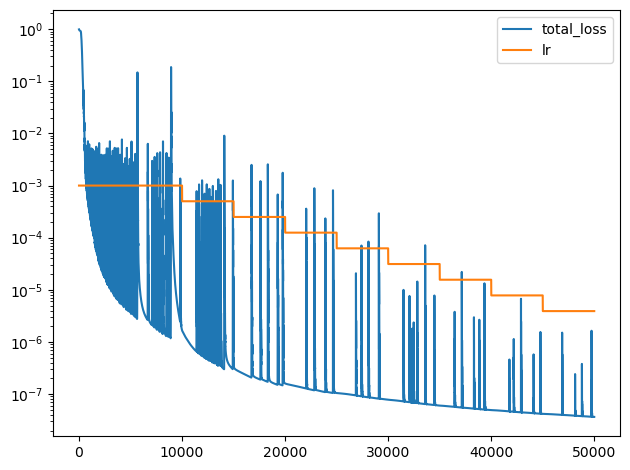

In [16]:
plt.semilogy(hist_inn['total_loss'][:], label='total_loss')
plt.semilogy(hist_inn['lr'][:],    label='lr')
plt.legend()
plt.tight_layout()

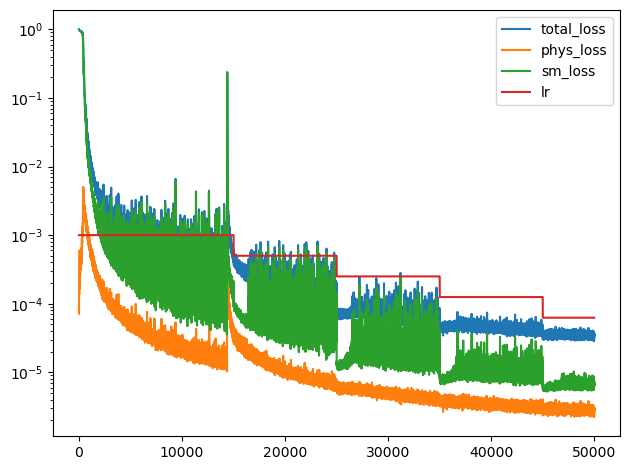

In [17]:
plt.semilogy(hist['total_loss'][:], label='total_loss')
plt.semilogy(hist['phys_loss'][:],  label='phys_loss')
plt.semilogy(hist['sm_loss'][:],    label='sm_loss')
plt.semilogy(hist['lr'][:],    label='lr')
plt.legend()
plt.tight_layout()

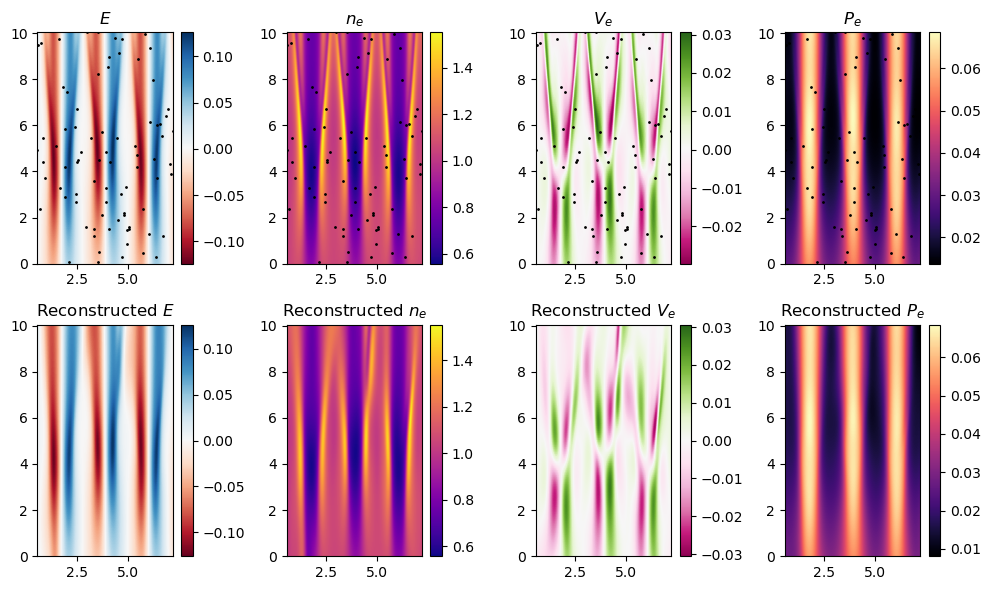

In [22]:
plot_NN_reconstruction(NN = Plasma_nn, 
                       i_xmin = i_xmin, i_xmax = i_xmax,
                       i_tmin = i_tmin, i_tmax = i_tmax,
                       x_sm = x_sm, t_sm = t_sm)

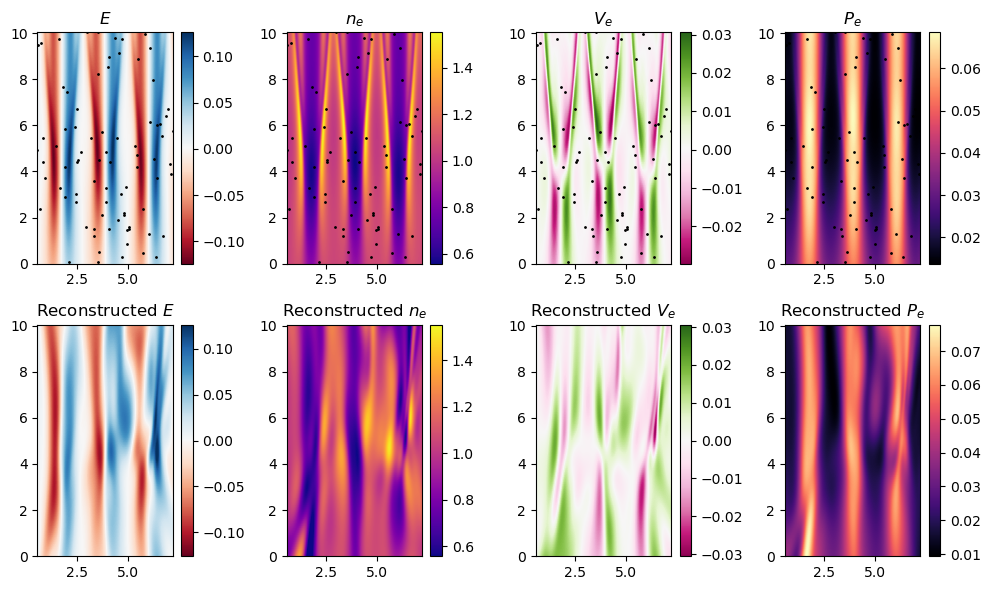

In [23]:
plot_NN_reconstruction(NN = Interp_nn, 
                       i_xmin = i_xmin, i_xmax = i_xmax,
                       i_tmin = i_tmin, i_tmax = i_tmax,
                       x_sm = x_sm, t_sm = t_sm)

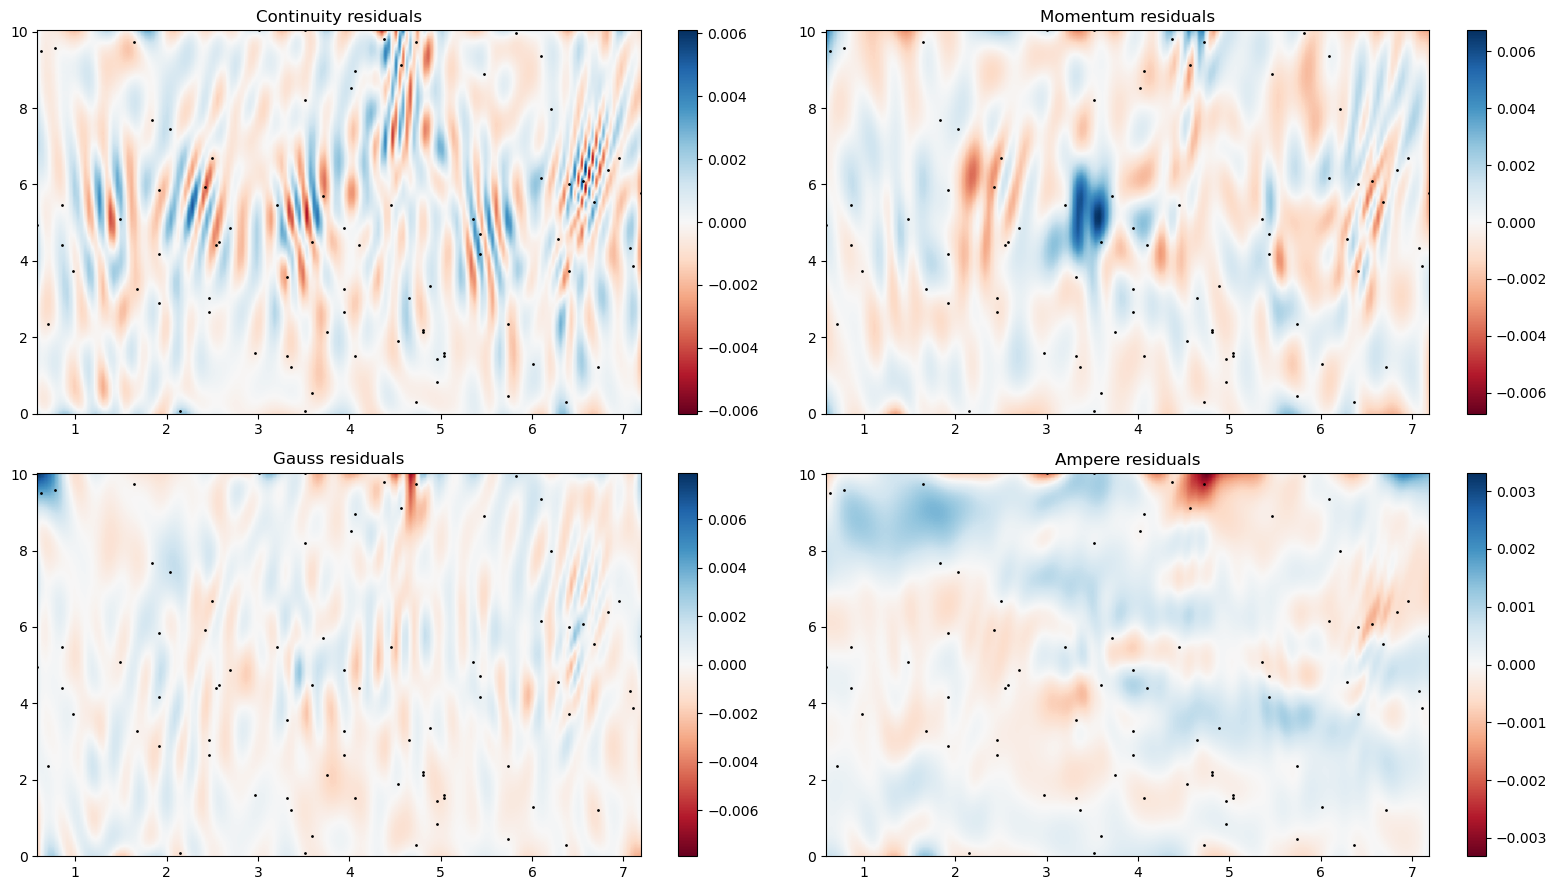

In [24]:
plot_phys_error_distribution(NN = Plasma_nn, 
                             i_xmin = i_xmin, i_xmax = i_xmax,
                             i_tmin = i_tmin, i_tmax = i_tmax,
                             x_sm = x_sm, t_sm = t_sm)